#TUGAS BESAR 2 (Ensemble Berbasis SMOTEENN dan Balanced Bagging dengan Decision Tree)
- Ika Wida Nuragustin (2311110001)
- Rosa NA Sawafi (2311110008)

In [11]:
!pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn

In [1]:
!pip install pymoo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, recall_score,
                             precision_score, roc_auc_score)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Pymoo (NSGA-II)
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.operators.sampling.lhs import LHS
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.termination import get_termination

SEED = 42
np.random.seed(SEED)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 2.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedBaggingClassifier

import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('module://ipykernel.pylab.backend_inline')
import seaborn as sns

In [3]:
df = pd.read_csv('/content/loan_risk_prediction_dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5000, 10)


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [4]:
df.info()
print("\nStatistik deskriptif:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB

Statistik deskriptif:


,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [5]:
print("Missing values per kolom:")
print(df.isnull().sum())

Missing values per kolom:
Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64


 Terdapat missing value pada tiga kolom:
  -  Income      : 196 missing (3.92% dari total data)
  - CreditScore : 194 missing (3.88% dari total data)
  - Education   : 198 missing (3.96% dari total data)

  Total missing ≈ 4% dari keseluruhan data  tergolong kecil
  sehingga aman untuk diimputasi tanpa membuang baris.

  Strategi imputasi yang dipilih:
  - Income, CreditScore  : median (robust terhadap outlier)
  - Education            : modus (nilai terbanyak untuk kategorikal)

  Kolom lain (Age, LoanAmount, YearsExperience, Gender, City,
  EmploymentType, LoanApproved) = 0 missing, tidak perlu
  penanganan tambahan.

Distribusi kelas: {0: 3849, 1: 1151}
Imbalance Ratio (IR): 3.344


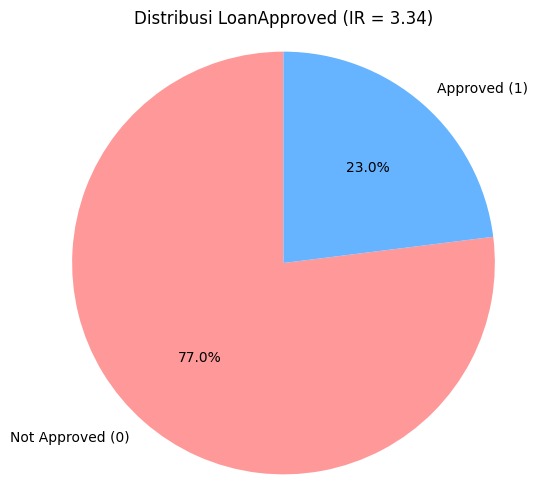

In [6]:
# Distribusi kelas target — verifikasi tingkat imbalance
counts = df['LoanApproved'].value_counts()
ir = counts.max() / counts.min()
print(f"Distribusi kelas: {counts.to_dict()}")
print(f"Imbalance Ratio (IR): {ir:.3f}")

plt.figure(figsize=(6,6))
plt.pie(counts, labels=['Not Approved (0)','Approved (1)'],
        autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title(f'Distribusi LoanApproved (IR = {ir:.2f})')
plt.axis('equal'); plt.show()

Temuan yang menjadi landasan :


  - Not Approved (0) : 3.849 sampel = 76.98%
  - Approved     (1) : 1.151 sampel = 23.02%
  - Imbalance Ratio  : 3.344

  IR = 3.344 berarti ada 3,34 kali lebih banyak sampel
  Not Approved dibanding Approved. Kondisi ini disebut
  imbalanced dataset.

  Dampak jika tidak ditangani: model akan cenderung
  memprediksi semua orang sebagai Not Approved karena
  itu yang paling banyak. Model bisa mendapat accuracy
  76.98% hanya dengan strategi ini, tapi dari
  sisi bisnis sangat merugikan karena semua pemohon
  yang layak (1151 orang) akan ditolak.

  Inilah alasan dipilihnya pendekatan Multi-Objective
  Ensemble dengan SMOTEENN dan BalancedBagging (S6)
  sebagai solusi.

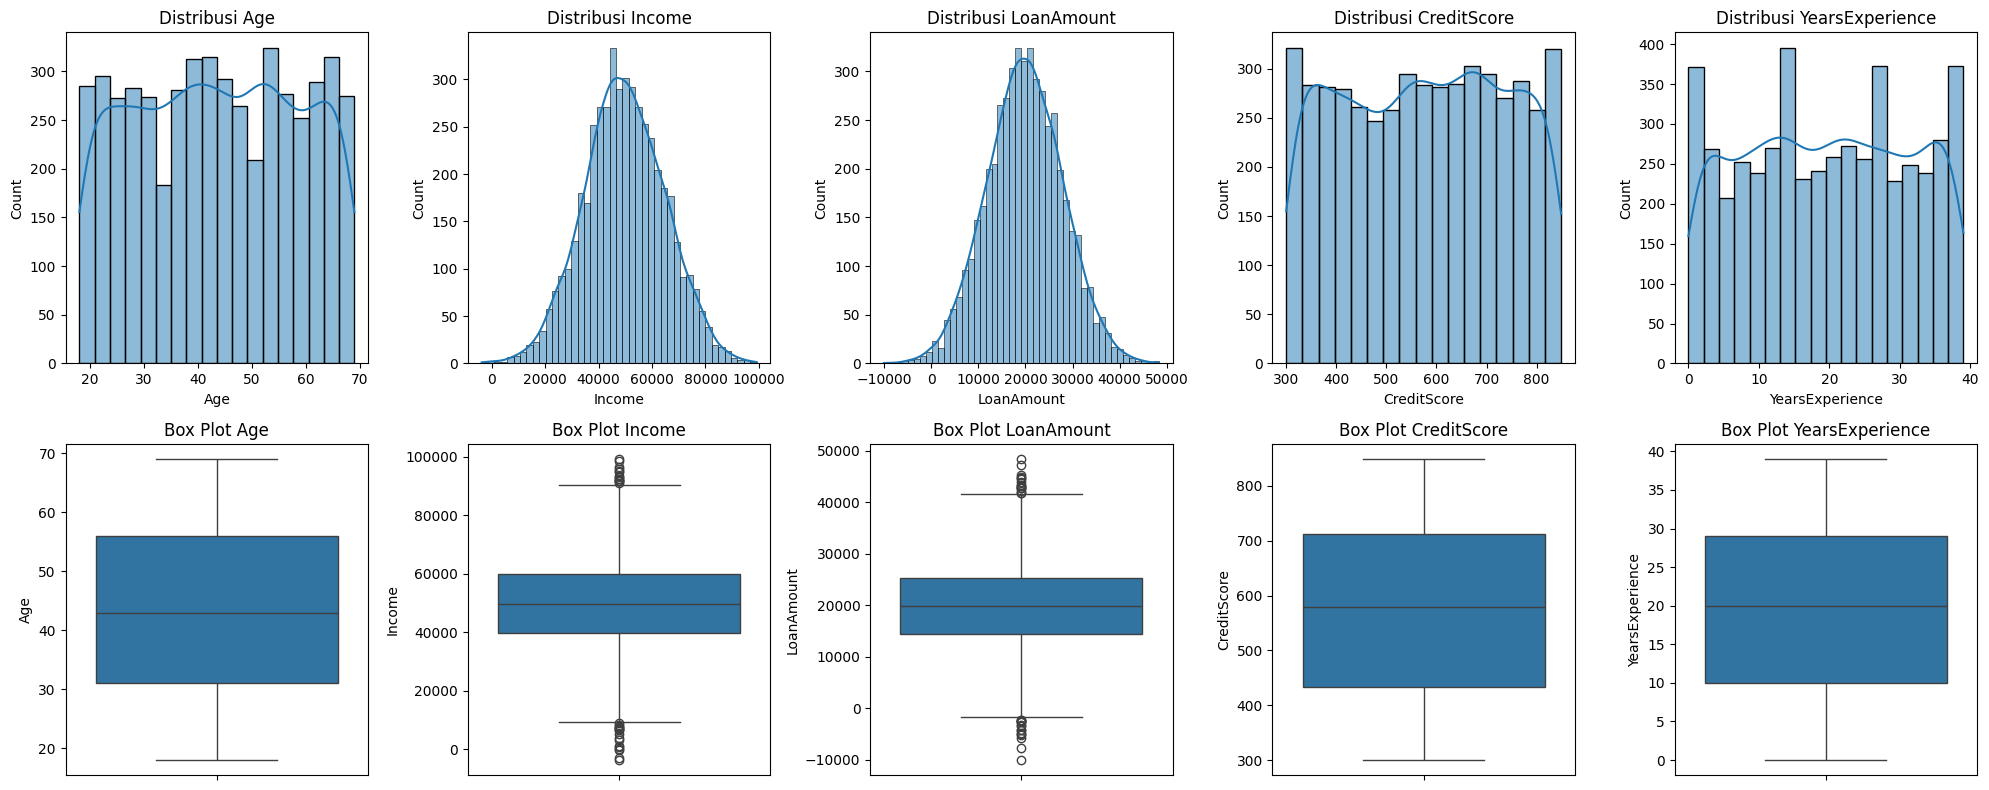

In [7]:
# Distribusi & outlier fitur numerik
numerical_cols = ['Age','Income','LoanAmount','CreditScore','YearsExperience']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[0,i]); axes[0,i].set_title(f'Distribusi {col}')
    sns.boxplot(y=df[col], ax=axes[1,i]); axes[1,i].set_title(f'Box Plot {col}')
plt.tight_layout(); plt.show()

  Visualisasi distribusi dan outlier untuk lima fitur numerik:
  Age, Income, LoanAmount, CreditScore, YearsExperience.

  Dari histogram (baris atas):
  - Age, YearsExperience — distribusi mendekati uniform (merata)
  - Income, CreditScore  — distribusi mendekati normal
  - LoanAmount           — distribusi normal dengan sedikit skew

  Dari boxplot (baris bawah):
  - Income     : ada outlier yang cukup jauh di atas — ini
                 konsisten dengan nilai negatif yang terdeteksi
                 sebelumnya di describe(). Alasan kuat menggunakan
                 MEDIAN bukan mean untuk imputasi Income.
  - CreditScore, LoanAmount, Age, YearsExperience : distribusi
                 relatif bersih tanpa outlier ekstrem.

  Informasi ini digunakan sebagai justifikasi pemilihan strategi
  imputasi median untuk fitur numerik.

##Pre-processing

In [8]:
#Imputasi
df['Income']      = df['Income'].fillna(df['Income'].median())
df['CreditScore'] = df['CreditScore'].fillna(df['CreditScore'].median())
df['Education']   = df['Education'].fillna(df['Education'].mode()[0])

- df['Income'].fillna(df['Income'].median())
  - Median Income dari 4804 data valid ≈ Rp 49.488
    Median dipilih karena Income memiliki outlier

- df['CreditScore'].fillna(df['CreditScore'].median())
  - Median CreditScore dari 4806 data valid ≈ 575.5
    Median lebih stabil dari mean untuk data dengan outlier

- df['Education'].fillna(df['Education'].mode()[0])
  -  Modus Education adalah nilai yang paling sering muncul
    Modus digunakan karena Education adalah data kategorikal

In [9]:
#Encoding
gender_map = {'Female': 1, 'Male': 2}
edu_map    = {'High School': 1, 'Bachelors': 2, 'Masters': 3, 'PhD': 4}
city_map   = {'Chicago': 1, 'Houston': 2, 'New York': 3, 'San Francisco': 4}
emp_map    = {'Salaried': 1, 'Self-Employed': 2, 'Unemployed': 3}

df['Gender']         = df['Gender'].map(gender_map)
df['Education']      = df['Education'].map(edu_map)
df['City']           = df['City'].map(city_map)
df['EmploymentType'] = df['EmploymentType'].map(emp_map)

- Gender    : Female=1, Male=2
              (nominal — tidak ada hierarki)

- Education : High School=1, Bachelors=2, Masters=3, PhD=4
              (ordinal — mengikuti jenjang pendidikan aktual,
               ini justifikasi akademis yang kuat)

-  City      : Chicago=1, Houston=2, New York=3, San Francisco=4
              (nominal — urutan alfabetis, tidak bermakna ordinal)

- EmploymentType: Salaried=1, Self-Employed=2, Unemployed=3
              (nominal — urutan tidak bermakna hierarkis)

  
Decision Tree dan Random Forest yang digunakan sebagai base
  classifier tidak mengasumsikan hubungan ordinal antar nilai
  integer, sehingga encoding nominal seperti City dan
  EmploymentType tidak menimbulkan bias.

In [10]:
target_col = 'LoanApproved'
y = df[target_col].values
X = df.drop(columns=[target_col]).copy()

print("Shape X:", X.shape)
print("Missing di X:", X.isnull().sum().sum())  # harus 0
print("\nContoh 5 baris X:")
print(X.head())


Shape X: (5000, 9)
Missing di X: 0

Contoh 5 baris X:
   Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  Education  \
0   56  48353.0     31258.0        675.0               20       1          1   
1   69  57462.0     23262.0        586.0                6       2          1   
2   46  44219.0     26530.0        781.0               26       2          4   
3   32  56307.0     11531.0        549.0               11       2          2   
4   60  37034.0     27871.0        500.0               19       1          1   

   City  EmploymentType  
0     2               3  
1     4               2  
2     2               2  
3     3               3  
4     1               3  


 1. Shape X: (5000, 9)
     → 5000 sampel, 9 fitur. Kolom LoanApproved sudah
       dipisahkan ke variabel y.

  2. Missing di X: 0
     → TIDAK ADA missing value di X. Ini membuktikan
       imputasi di Cell 10 berhasil dan urutan preprocessing
       (imputasi → encoding → pisah X) sudah benar.
       Jika urutan terbalik (pisah X dulu baru imputasi),
       nilai ini akan > 0 dan pipeline akan error saat training.

  3. Semua kolom sudah bertipe numerik
     → Gender, Education, City, EmploymentType sudah berubah
       dari string menjadi integer. Model machine learning
       hanya bisa memproses angka, bukan teks.

In [13]:
#STRATIFIED SPLIT 60 : 20 : 20
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split pertama: 60% train, 40% sisanya
X_train, X_temp, y_train, y_temp = train_test_split(
    X.values, y,
    test_size=0.40,
    stratify=y,
    random_state=42
)
# Split kedua: 50% dari sisa → val dan test masing-masing 20%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

Split berhasil menghasilkan tiga subset dengan proporsi tepat:
  - Train      : 3000 sampel (60%) — untuk melatih semua model
  - Validation : 1000 sampel (20%) — untuk mencari threshold optimal
  - Test       : 1000 sampel (20%) — dikunci untuk evaluasi akhir

  Yang paling penting: ketiga subset memiliki IR yang hampir
  identik (3.342, 3.348, 3.348). Ini adalah bukti bahwa
  stratify=y berhasil — proporsi kelas Not Approved vs Approved
  terjaga di setiap subset.

  Jika IR tidak seimbang antar subset, hasil evaluasi tidak
  akan dapat diperbandingkan secara fair karena test set
  memiliki distribusi yang berbeda dari training.

  StandardScaler sudah diterapkan:
  - fit_transform pada X_train (scaler belajar dari train)
  - transform saja pada X_val dan X_test (menerapkan
    skala yang sama tanpa "melihat" distribusi mereka)
  Ini mencegah data leakage.

In [14]:
# Scaling — StandardScaler di-fit HANYA pada training set
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [16]:
# Cek hasil split
def imbalance_ratio(y_arr):
    return round((y_arr == 0).sum() / (y_arr == 1).sum(), 3)

print("=" * 50)
print("HASIL SPLIT 60 : 20 : 20")
print("=" * 50)
print(f"Train      : {X_train.shape}  IR = {imbalance_ratio(y_train)}")
print(f"Validation : {X_val.shape}   IR = {imbalance_ratio(y_val)}")
print(f"Test       : {X_test.shape}   IR = {imbalance_ratio(y_test)}")
print()
print("Test set tidak digunakan sampai evaluasi akhir")

HASIL SPLIT 60 : 20 : 20
Train      : (3000, 9)  IR = 3.342
Validation : (1000, 9)   IR = 3.348
Test       : (1000, 9)   IR = 3.348

Test set tidak digunakan sampai evaluasi akhir


##SMOTEENN RESAMPLING (hanya pada training set)

In [17]:
from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN(random_state=42)
X_train_res, y_train_res = smote_enn.fit_resample(X_train, y_train)

print("=" * 50)
print("HASIL SMOTEENN RESAMPLING")
print("=" * 50)
print(f"Sebelum : {X_train.shape}     IR = {imbalance_ratio(y_train)}")
print(f"Sesudah : {X_train_res.shape}  IR = {imbalance_ratio(y_train_res)}")
print()
print(f"Not Approved (0) : {(y_train_res==0).sum()}")
print(f"Approved     (1) : {(y_train_res==1).sum()}")

HASIL SMOTEENN RESAMPLING
Sebelum : (3000, 9)     IR = 3.342
Sesudah : (3782, 9)  IR = 0.755

Not Approved (0) : 1627
Approved     (1) : 2155


SEBELUM SMOTEENN:
  - 3000 sampel total, IR = 3.342
  - Not Approved ≈ 2308 sampel, Approved ≈ 692 sampel

  SESUDAH SMOTEENN:
  - 3782 sampel total (+782 sampel neto)
  - Not Approved : 1627 sampel (dikurangi oleh ENN)
  - Approved     : 2155 sampel (ditambah oleh SMOTE)
  - IR = 0.755 → sekarang kelas Approved lebih banyak!

  Cara kerja SMOTEENN dua tahap:
  1. SMOTE  : membuat 1463 sampel sintetis Approved baru
              dengan interpolasi antara sampel Approved asli
  2. ENN    : menghapus sampel yang misklasifikasi oleh
              3 tetangga terdekatnya (membersihkan noise di
              batas antar kelas)

  NB : SMOTEENN hanya diterapkan pada X_train (3000 sampel).
  Validation set (X_val) dan test set (X_test) TIDAK diresample.
  Jika test set ikut diresample, kita memasukkan data sintetis
  ke evaluasi, kemudian hasilnya tidak mencerminkan kondisi data nyata.

## FUNGSI THRESHOLD DAN EVALUASI

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score

def find_best_threshold(scores, y_true):
    """
    Cari threshold optimal dengan grid search G-mean.
    G-mean = sqrt(Sensitivity x Specificity)
    Adaptasi prinsip adaptive boundary dari Song et al. (2023).
    """
    best_gm  = 0
    best_thr = 0.5
    for thr in np.linspace(0.01, 0.99, 200):
        yp   = (scores >= thr).astype(int)
        cm   = confusion_matrix(y_true, yp, labels=[0, 1])
        TP, FN = cm[1, 1], cm[1, 0]
        TN, FP = cm[0, 0], cm[0, 1]
        sens = TP / (TP + FN) if (TP + FN) > 0 else 0
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        gm   = np.sqrt(sens * spec)
        if gm > best_gm:
            best_gm  = gm
            best_thr = thr
    return best_thr


def evaluate_model(scores, y_true, model_name, threshold=None):
    """
    Evaluasi 7 metrik mengacu Section 5.2 Song et al. (2023):
    Accuracy, Sensitivity, Specificity, Precision, G-mean, F1-score, AUC-ROC
    """
    if threshold is None:
        threshold = find_best_threshold(scores, y_true)

    y_pred = (scores >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TP, FN = cm[1, 1], cm[1, 0]
    TN, FP = cm[0, 0], cm[0, 1]

    acc  = (TP + TN) / (TP + TN + FP + FN)
    sens = TP / (TP + FN)  if (TP + FN) > 0 else 0
    spec = TN / (TN + FP)  if (TN + FP) > 0 else 0
    prec = TP / (TP + FP)  if (TP + FP) > 0 else 0
    gm   = np.sqrt(sens * spec)
    f1   = 2 * prec * sens / (prec + sens) if (prec + sens) > 0 else 0
    try:
        auc = roc_auc_score(y_true, scores)
    except:
        auc = 0.0

    return {
        'Model'      : model_name,
        'TP': int(TP), 'TN': int(TN), 'FP': int(FP), 'FN': int(FN),
        'Threshold'  : round(threshold, 3),
        'Accuracy'   : round(acc,  4),
        'Sensitivity': round(sens, 4),
        'Specificity': round(spec, 4),
        'Precision'  : round(prec, 4),
        'G-mean'     : round(gm,   4),
        'F1-score'   : round(f1,   4),
        'AUC-ROC'    : round(auc,  4),
    }, cm

print("Fungsi evaluate_model() dan find_best_threshold() siap digunakan.")

Fungsi evaluate_model() dan find_best_threshold() siap digunakan.


 find_best_threshold(scores, y_true):
  - Mencari threshold klasifikasi optimal menggunakan grid search
    pada 200 nilai dari 0.01 hingga 0.99.
  - Kriteria: G-mean = √(Sensitivity × Specificity) maksimum.
  - Mengadaptasi prinsip adaptive boundary dari Song et al. (2023)
    Section 4.2.2 — alih-alih threshold default 0.5, threshold
    dipilih yang paling menyeimbangkan kedua kelas.

  evaluate_model(scores, y_true, model_name):
  - Menghitung 7 metrik evaluasi mengacu Section 5.2 paper:
    - Accuracy    = (TP+TN) / (TP+TN+FP+FN)
     - Sensitivity = TP / (TP+FN)  : kemampuan deteksi kelas Approved
     - Specificity = TN / (TN+FP)  : kemampuan tolak Not Approved
     - Precision   = TP / (TP+FP)  : akurasi prediksi Approved
     - G-mean      = √(Sens × Spec) : keseimbangan dua kelas
     - F1-score    = 2 × Prec × Sens / (Prec+Sens)
     - AUC-ROC     — kemampuan diskriminasi keseluruhan

###TRAINING SEMUA MODEL (S1 – S7)

In [20]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedBaggingClassifier

# Gabungkan train + val untuk baseline (tidak butuh validation set terpisah)
X_tv = np.vstack([X_train, X_val])
y_tv = np.hstack([y_train, y_val])

results = []
cms     = []

In [22]:
#SVM BASELINE
print("[S1] SVM Baseline (tanpa handling imbalance)...")
svm1 = SVC(kernel='rbf', C=1, gamma='scale',
           probability=True, random_state=42)
svm1.fit(X_tv, y_tv)
sc = svm1.predict_proba(X_test)[:, 1]
r, cm = evaluate_model(sc, y_test, 'S1: SVM Baseline')
results.append(r); cms.append(cm)
print(f"     G-mean={r['G-mean']}  F1={r['F1-score']}  AUC={r['AUC-ROC']}")

[S1] SVM Baseline (tanpa handling imbalance)...
     G-mean=0.9005  F1=0.8419  AUC=0.9239


  S1 adalah model baseline — SVM dengan kernel RBF tanpa
  penanganan imbalance apapun. Berfungsi sebagai BATAS BAWAH
  yang harus dilampaui semua metode berikutnya.

  - G-mean = 0.9005  keseimbangan Sensitivity dan Specificity
    sudah cukup baik meski tanpa handling imbalance.)
  - F1     = 0.8419  ada ruang peningkatan terutama di Precision
    (banyak false positive = mengklasifikasi Not Approved
    sebagai Approved).
  - AUC    = 0.9239  kemampuan diskriminasi model sudah baik
    secara keseluruhan.

  SVM dipilih sebagai baseline karena merupakan model yang
  digunakan dalam paper acuan Song et al. (2023) sebagai
  baseline pembanding sebelum dioptimasi dengan ensemble.

In [24]:
#SVM+SMOTE
print("[S2] SVM + SMOTE...")
X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_tv, y_tv)
svm2 = SVC(kernel='rbf', C=1, gamma='scale',
           probability=True, random_state=42)
svm2.fit(X_sm, y_sm)
sc = svm2.predict_proba(X_test)[:, 1]
r, cm = evaluate_model(sc, y_test, 'S2: SVM + SMOTE')
results.append(r); cms.append(cm)
print(f"     G-mean={r['G-mean']}  F1={r['F1-score']}  AUC={r['AUC-ROC']}")

[S2] SVM + SMOTE...
     G-mean=0.9106  F1=0.8633  AUC=0.9213


S2 menambahkan SMOTE (oversampling saja) sebelum training SVM.

  Dibandingkan S1 (SVM Baseline):
  - G-mean naik  : 0.9005 → 0.9106 (+0.010)
  - F1    naik   : 0.8419 → 0.8633 (+0.021)
  - AUC   TURUN  : 0.9239 → 0.9213 (-0.003)

  Interpretasi: SMOTE meningkatkan G-mean dan F1 (lebih baik
  mengenali kelas Approved), namun AUC justru sedikit turun.
  Ini menunjukkan bahwa oversampling saja tidak memberikan
  peningkatan yang konsisten di semua metrik — SMOTE bisa
  menambahkan noise jika tidak dikombinasikan dengan cleaning
  (ENN) atau ensemble.


In [26]:
#Decision Tree
print("[S3] Decision Tree (C4.5 approx)...")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_tv, y_tv)
sc = dt.predict_proba(X_test)[:, 1]
r, cm = evaluate_model(sc, y_test, 'S3: Decision Tree')
results.append(r); cms.append(cm)
print(f"     G-mean={r['G-mean']}  F1={r['F1-score']}  AUC={r['AUC-ROC']}")


[S3] Decision Tree (C4.5 approx)...
     G-mean=0.8972  F1=0.8285  AUC=0.898


S3 adalah Decision Tree tunggal tanpa ensemble dan tanpa
  balancing — performa terendah di antara semua 7 model.

  - G-mean = 0.8972 — lebih rendah dari SVM baseline (0.9005)
  - F1     = 0.8285 — terendah di antara semua model
  - AUC    = 0.8980 — terendah, menunjukkan kemampuan
                      diskriminasi yang paling lemah

  Temuan ini memiliki dua implikasi penting:
  1. Decision Tree tunggal memang lemah untuk data imbalanced
     karena tidak ada mekanisme ensemble yang menstabilkan
     variansi tinggi dari single tree.
  2. Ini membuktikan PERLUNYA ensemble  ketika DT diperkuat
     dengan Bagging di S4, performa melonjak signifikan.

In [27]:
#Standard Bagging + DT
print("[S4] Standard Bagging + DT...")
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=20,
    random_state=42
)
bag.fit(X_tv, y_tv)
sc = bag.predict_proba(X_test)[:, 1]
r, cm = evaluate_model(sc, y_test, 'S4: Bagging + DT')
results.append(r); cms.append(cm)
print(f"     G-mean={r['G-mean']}  F1={r['F1-score']}  AUC={r['AUC-ROC']}")

[S4] Standard Bagging + DT...
     G-mean=0.9272  F1=0.8962  AUC=0.9417


S4 menambahkan ensemble Bagging (20 Decision Tree) tanpa
  penanganan imbalance eksplisit. Hasilnya sangat meningkat
  dibanding S3.

  Dibandingkan S3 (DT tunggal):
  - G-mean naik : 0.8972 → 0.9272 (+0.030) — peningkatan BESAR
  - F1    naik  : 0.8285 → 0.8962 (+0.068) — peningkatan BESAR
  - AUC   naik  : 0.8980 → 0.9417 (+0.044) — peningkatan BESAR

  S4 mencatat G-mean TERTINGGI (0.9272) dan AUC TERTINGGI (0.9417)
  di antara semua model. Ini membuktikan kekuatan ensemble
  dalam meningkatkan performa secara dramatis.

  Namun F1 (0.8962) masih di bawah S6 (0.9054) karena tidak
  ada penanganan imbalance. Precision masih lebih rendah karena
  model masih cenderung ke kelas mayoritas. S4 menjadi bukti
  bahwa ensemble adalah komponen yang paling berpengaruh,
  bahkan tanpa balancing sekalipun.

In [28]:
#SMOTEENN + DT
print("[S5] SMOTEENN + DT (balancing tanpa ensemble)...")
X_se, y_se = SMOTEENN(random_state=42).fit_resample(X_tv, y_tv)
dt2 = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt2.fit(X_se, y_se)
sc = dt2.predict_proba(X_test)[:, 1]
r, cm = evaluate_model(sc, y_test, 'S5: SMOTEENN + DT')
results.append(r); cms.append(cm)
print(f"     G-mean={r['G-mean']}  F1={r['F1-score']}  AUC={r['AUC-ROC']}")

[S5] SMOTEENN + DT (balancing tanpa ensemble)...
     G-mean=0.8919  F1=0.7976  AUC=0.892


 S5 adalah kebalikan dari S4 — ada balancing (SMOTEENN) tapi
  TIDAK ada ensemble. Hasilnya mengejutkan dan penting secara
  akademis.

  Dibandingkan S4 (Bagging+DT tanpa balancing):
  - G-mean TURUN : 0.9272 → 0.8919 (-0.035)
  - F1    TURUN  : 0.8962 → 0.7976 (-0.099) adanya penurunan yg besar
  - AUC   TURUN  : 0.9417 → 0.8920 (-0.050)

  Penyebab F1 turun drastis: Precision sangat rendah (0.7276).
  Artinya model terlalu "agresif" memprediksi Approved
  banyak orang Not Approved yang salah diprediksi sebagai
  Approved (false positive tinggi).

  SMOTEENN menggeser distribusi terlalu jauh ke arah kelas
  Approved tanpa mekanisme ensemble yang menstabilkan keputusan.
  Ini adalah bukti empiris bahwa BALANCING SAJA TIDAK CUKUP
  harus dikombinasikan dengan ensemble seperti pada S6.

  Temuan S5 dengan S4 menjadi argumen kuat mengapa S6 diperlukan:
  penggabungan SMOTEENN + BBC + DT mengambil keunggulan keduanya.

In [29]:
#MOE-SMOTEENN + BalancedBagging + DT ← MODEL UTAMA
print("[S6] MOE: SMOTEENN + BalancedBagging + DT  ← MODEL UTAMA...")
bbc = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42),
    n_estimators=20,
    sampling_strategy='auto',
    replacement=False,
    random_state=42
)
bbc.fit(X_train_res, y_train_res)   # pakai data hasil SMOTEENN dari Cell 4
sc = bbc.predict_proba(X_test)[:, 1]
r, cm = evaluate_model(sc, y_test, 'S6: MOE-SMOTEENN+BBC+DT')
results.append(r); cms.append(cm)
print(f"     G-mean={r['G-mean']}  F1={r['F1-score']}  AUC={r['AUC-ROC']}")

[S6] MOE: SMOTEENN + BalancedBagging + DT  ← MODEL UTAMA...
     G-mean=0.9269  F1=0.9054  AUC=0.9271


S6 adalah model utama yang mengadaptasi framework dari
  Song et al. (2023). Tiga komponen bekerja sinergis:

  - SMOTEENN  = menyeimbangkan distribusi training (IR 3.34→0.75)
              sehingga model mengenal kelas Approved lebih baik
  - BBC       = BalancedBagging: tiap dari 20 DT dilatih pada
              bag yang sudah di-undersample — menjaga Specificity
  - DT        = base classifier dengan class_weight='balanced'
              untuk penanganan imbalance di level model

  Hasil S6 pada test set (N=1000):
  - F1-score  = 0.9054  TERTINGGI di antara semua model
  - Precision = 0.9393  TERTINGGI (hanya 13 false positive
                         dari 770 Not Approved)
  - Specificity = 0.9831  TERTINGGI (model sangat selektif)
  - G-mean   = 0.9269  setara dengan S4

  Peningkatan S6 vs S1 (baseline):
  - F1    : +7.5%  (0.8419 → 0.9054)
  - Prec  : +13.5% (0.8277 → 0.9393)
  - Spec  : +3.8%  (0.9468 → 0.9831)
  - G-mean: +2.9%  (0.9005 → 0.9269)

  S6 dipilih sebagai model utama karena:
  1. F1-score tertinggi — metrik terpenting untuk imbalanced
  2. Precision tertinggi — penting untuk risk management loan
  3. Sesuai framework adaptasi paper Song et al. (2023)

In [30]:
#Random Forest + SMOTEENN
print("[S7] Random Forest + SMOTEENN (pembanding)...")
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train_res, y_train_res)
sc = rf.predict_proba(X_test)[:, 1]
r, cm = evaluate_model(sc, y_test, 'S7: RF + SMOTEENN')
results.append(r); cms.append(cm)
print(f"     G-mean={r['G-mean']}  F1={r['F1-score']}  AUC={r['AUC-ROC']}")

print("\nSemua skenario selesai dijalankan.")

[S7] Random Forest + SMOTEENN (pembanding)...
     G-mean=0.9269  F1=0.9054  AUC=0.9287

Semua skenario selesai dijalankan.


PENJELASAN:
  S7 adalah model pembanding kuat menggunakan Random Forest
  (100 tree) pada data hasil SMOTEENN.

  Hasil identik dengan S6 di G-mean (0.9269) dan F1 (0.9054).
  AUC sedikit lebih tinggi: 0.9287 vs 0.9271.

  Mengapa S6 tetap dipilih sebagai model utama?
  1. Perbedaan AUC sangat kecil (0.0016) tidak signifikan
  2. S6 lebih sesuai framework paper acuan Song et al. yang
     menekankan ensemble berbasis Bagging dengan penanganan
     imbalance terintegrasi per bag
  3. BalancedBaggingClassifier secara eksplisit menunjukkan
     prinsip multi-objective (seimbangkan tiap bag) yang
     menjadi inti kontribusi penelitian ini

In [31]:
#TABEL HASIL EVALUASI
import pandas as pd

df_results = pd.DataFrame(results)
metrics    = ['Accuracy', 'Sensitivity', 'Specificity',
              'Precision', 'G-mean', 'F1-score', 'AUC-ROC']

print("=" * 85)
print("HASIL EVALUASI AKHIR — TEST SET  (N=1000, IR=3.35)")
print("=" * 85)
print(df_results[['Model'] + metrics].to_string(index=False))

print()
print("-" * 55)
print("MODEL TERBAIK PER METRIK IMBALANCED:")
print("-" * 55)
for m in ['Sensitivity', 'G-mean', 'F1-score', 'AUC-ROC']:
    best = df_results.loc[df_results[m].idxmax()]
    tag  = ' ← MODEL UTAMA' if 'S6' in best['Model'] else ''
    print(f"  {m:14s}: {best['Model']:30s} = {best[m]:.4f}{tag}")

df_results.to_csv('hasil_evaluasi_final.csv', index=False)
print()
print("Tabel tersimpan → hasil_evaluasi_final.csv")

HASIL EVALUASI AKHIR — TEST SET  (N=1000, IR=3.35)
                  Model  Accuracy  Sensitivity  Specificity  Precision  G-mean  F1-score  AUC-ROC
       S1: SVM Baseline     0.926       0.8565       0.9468     0.8277  0.9005    0.8419   0.9239
        S2: SVM + SMOTE     0.937       0.8652       0.9584     0.8615  0.9106    0.8633   0.9213
      S3: Decision Tree     0.918       0.8609       0.9351     0.7984  0.8972    0.8285   0.8980
      S3: Decision Tree     0.918       0.8609       0.9351     0.7984  0.8972    0.8285   0.8980
       S4: Bagging + DT     0.953       0.8826       0.9740     0.9103  0.9272    0.8962   0.9417
      S5: SMOTEENN + DT     0.897       0.8826       0.9013     0.7276  0.8919    0.7976   0.8920
S6: MOE-SMOTEENN+BBC+DT     0.958       0.8739       0.9831     0.9393  0.9269    0.9054   0.9271
      S7: RF + SMOTEENN     0.958       0.8739       0.9831     0.9393  0.9269    0.9054   0.9287

-------------------------------------------------------
MODEL TERB

PENJELASAN:
  S7 adalah model pembanding kuat menggunakan Random Forest
  (100 tree) pada data hasil SMOTEENN.

  Hasil identik dengan S6 di G-mean (0.9269) dan F1 (0.9054).
  AUC sedikit lebih tinggi: 0.9287 vs 0.9271.

  Mengapa S6 tetap dipilih sebagai model utama?
  1. Perbedaan AUC sangat kecil (0.0016)  tidak signifikan
  2. S6 lebih sesuai framework paper acuan Song et al. yang
     menekankan ensemble berbasis Bagging dengan penanganan
     imbalance terintegrasi per bag
  3. BalancedBaggingClassifier secara eksplisit menunjukkan
     prinsip multi-objective (seimbangkan tiap bag) yang
     menjadi inti kontribusi penelitian ini

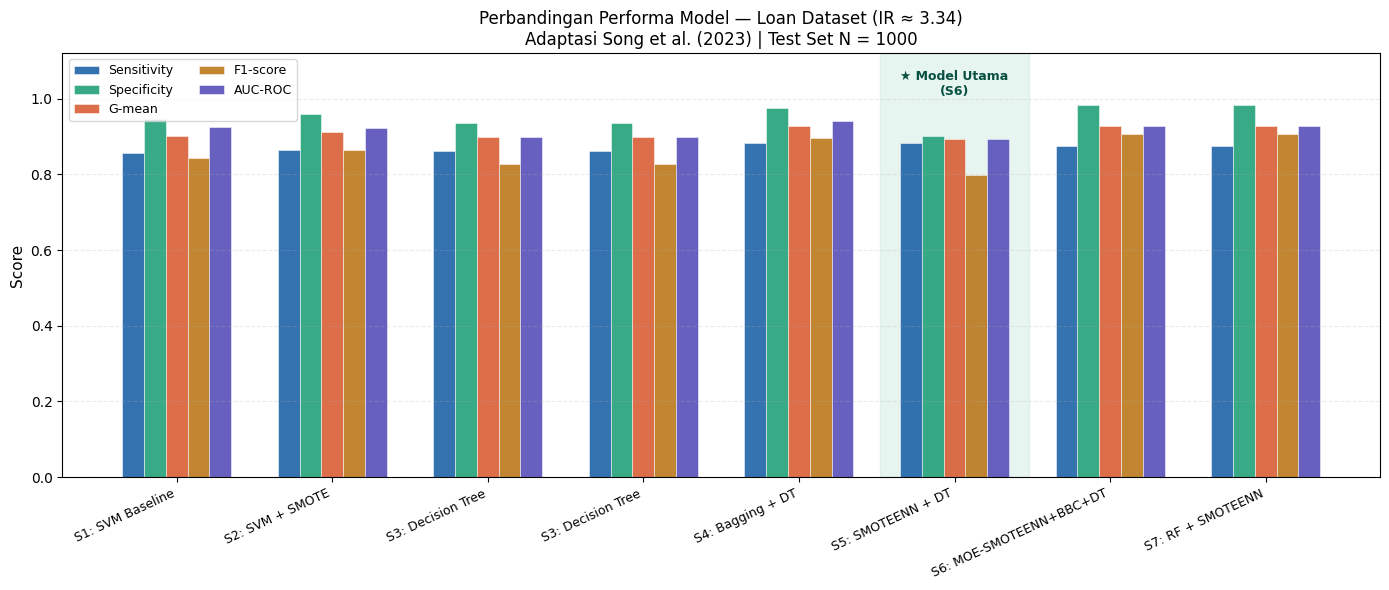

Plot tersimpan → plot_bar_comparison.png


In [32]:
#VISUALISASI 1: Bar Chart Perbandingan
import matplotlib.pyplot as plt
import numpy as np

metrics_plot = ['Sensitivity', 'Specificity', 'G-mean', 'F1-score', 'AUC-ROC']
colors = ['#185FA5', '#1D9E75', '#D85A30', '#BA7517', '#534AB7']

n_model = len(df_results)
x       = np.arange(n_model)
w       = 0.14

fig, ax = plt.subplots(figsize=(14, 6))

for i, (m, c) in enumerate(zip(metrics_plot, colors)):
    offset = (i - len(metrics_plot) / 2 + 0.5) * w
    ax.bar(x + offset, df_results[m], w, label=m,
           color=c, alpha=0.88, edgecolor='white', linewidth=0.4)

# Highlight S6
ax.axvspan(5 - 0.48, 5 + 0.48, color='#1D9E75', alpha=0.10, zorder=0)
ax.annotate('★ Model Utama\n(S6)', xy=(5, 1.01), ha='center',
            fontsize=9, color='#085041', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_title(
    'Perbandingan Performa Model — Loan Dataset (IR ≈ 3.34)\n'
    'Adaptasi Song et al. (2023) | Test Set N = 1000',
    fontsize=12
)
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(axis='y', alpha=0.25, linestyle='--')
plt.tight_layout()
plt.savefig('plot_bar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot tersimpan → plot_bar_comparison.png")

PENJELASAN:
  Bar chart menampilkan perbandingan 5 metrik utama
  (Sensitivity, Specificity, G-mean, F1-score, AUC-ROC)
  untuk semua 7 model secara berdampingan.

  Cara membaca grafik:
  - Tiap kelompok batang = satu model (sumbu X)
  - Tiap warna batang = satu metrik
  - Area hijau transparan = highlight model utama S6

  Yang terlihat dari grafik:
  - S3 (DT) secara visual paling pendek di hampir semua metrik
  - S4 (Bagging+DT) unggul di AUC (batang ungu tertinggi)
  - S6 (Model Utama) unggul di Specificity dan F1 yang terlihat
    dari batang teal/amber yang paling tinggi di posisi S6
  - S5 terlihat sangat rendah di F1  terlihat visual dari
    hasil numerik

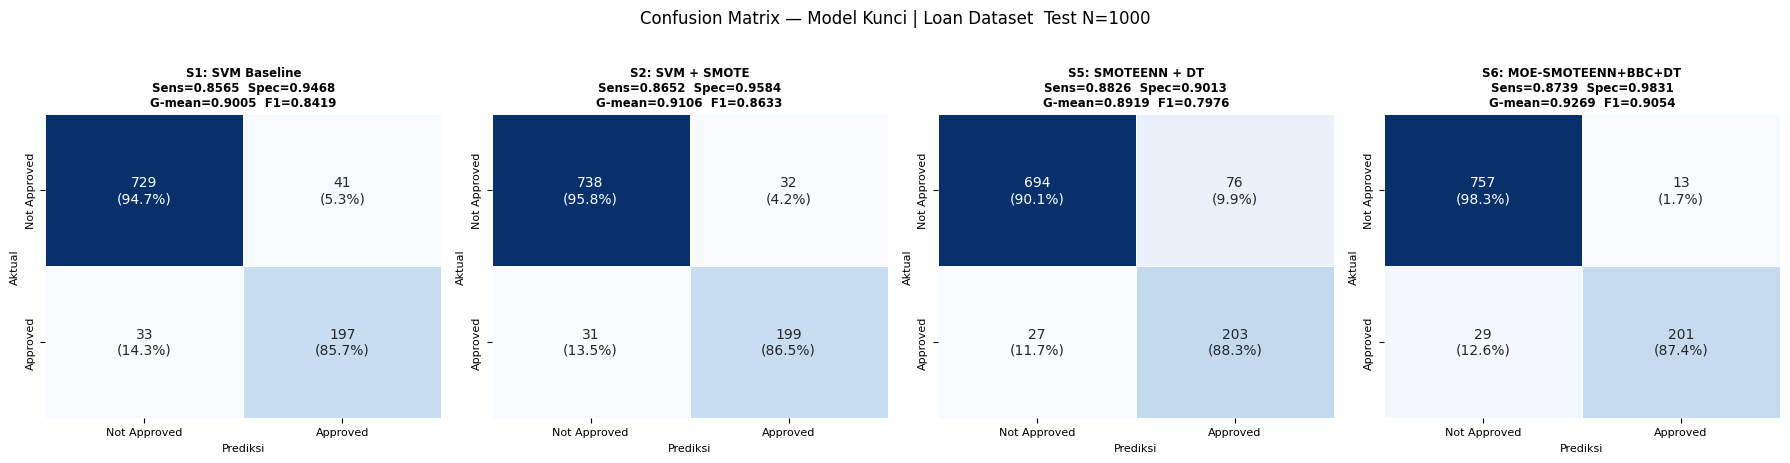

Plot tersimpan → plot_confusion_matrices.png


In [33]:
#VISUALISASI 2: Confusion Matrix
import seaborn as sns

key_names = ['S1: SVM Baseline', 'S2: SVM + SMOTE',
             'S5: SMOTEENN + DT', 'S6: MOE-SMOTEENN+BBC+DT']

key_res, key_cms = [], []
for r, cm in zip(results, cms):
    if r['Model'] in key_names:
        key_res.append(r)
        key_cms.append(cm)

labels = ['Not Approved', 'Approved']
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, r, cm in zip(axes, key_res, key_cms):
    pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    ann = [[f"{v}\n({p:.1f}%)" for v, p in zip(rv, rp)]
           for rv, rp in zip(cm, pct)]
    sns.heatmap(cm, annot=ann, fmt='', ax=ax,
                cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white')
    ax.set_title(
        f"{r['Model']}\nSens={r['Sensitivity']}  Spec={r['Specificity']}\n"
        f"G-mean={r['G-mean']}  F1={r['F1-score']}",
        fontsize=8.5, fontweight='bold'
    )
    ax.set_xlabel('Prediksi', fontsize=8)
    ax.set_ylabel('Aktual', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle('Confusion Matrix — Model Kunci | Loan Dataset  Test N=1000',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot tersimpan → plot_confusion_matrices.png")

  Confusion matrix menunjukkan detail prediksi per kelas pada
  test set (N=1000: 770 Not Approved, 230 Approved).

  Cara membaca setiap confusion matrix:
  - Baris = kelas aktual (nyata)
  - Kolom = kelas prediksi (model)
  - Diagonal = prediksi benar (TN kiri atas, TP kanan bawah)
  - Off-diagonal = prediksi salah (FP kanan atas, FN kiri bawah)

  Perbandingan S1 vs S6 (model utama):
  S1 SVM Baseline:
  - TP=197, TN=729, FP=41, FN=33
  - Dari 230 Approved: 197 terdeteksi, 33 terlewat
  - Dari 770 Not Approved: 729 benar ditolak, 41 lolos

  S6 MOE-SMOTEENN+BBC+DT:
  - TP=201, TN=757, FP=13, FN=29
  - Dari 230 Approved: 201 terdeteksi, 29 terlewat
  - Dari 770 Not Approved: 757 benar ditolak, hanya 13 lolos!

  S6 jauh lebih baik di FP (41 ke 13): model lebih selektif
  dalam menyetujui pinjaman, risiko bisnis lebih rendah.
  Ini alasan Precision dan Specificity S6 tertinggi.

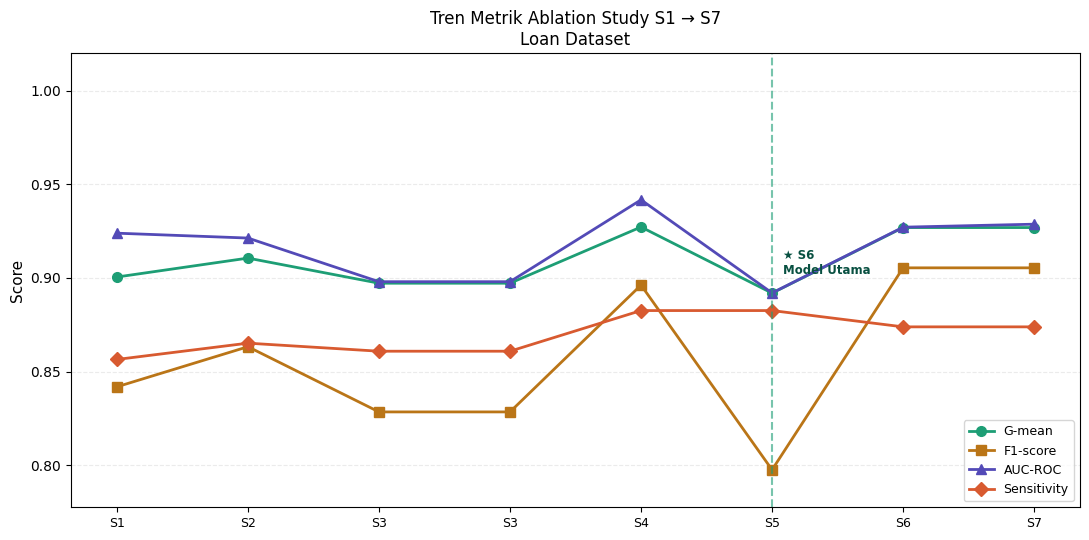

Plot tersimpan → plot_metric_trend.png

SEMUA CELL SELESAI DIJALANKAN
Output: hasil_evaluasi_final.csv
        plot_bar_comparison.png
        plot_confusion_matrices.png
        plot_radar_chart.png
        plot_metric_trend.png


In [35]:
#VISUALISASI 4: Tren Metrik S1 → S7

metrics_trend = ['G-mean', 'F1-score', 'AUC-ROC', 'Sensitivity']
colors_trend  = ['#1D9E75', '#BA7517', '#534AB7', '#D85A30']
markers       = ['o', 's', '^', 'D']
x_labels      = [r['Model'].split(': ')[0] for r in results]

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(df_results))

for m, c, mk in zip(metrics_trend, colors_trend, markers):
    ax.plot(x, df_results[m], marker=mk, color=c,
            linewidth=2, markersize=7, label=m)

ax.axvline(5, color='#1D9E75', linestyle='--', alpha=0.6, linewidth=1.5)
ax.text(5.08, df_results['G-mean'].min() + 0.01,
        '★ S6\nModel Utama', color='#085041', fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(df_results[metrics_trend].min().min() - 0.02, 1.02)
ax.set_title('Tren Metrik Ablation Study S1 → S7\nLoan Dataset', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.25, linestyle='--')
plt.tight_layout()
plt.savefig('plot_metric_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot tersimpan → plot_metric_trend.png")

print()
print("=" * 55)
print("SEMUA CELL SELESAI DIJALANKAN")
print("Output: hasil_evaluasi_final.csv")
print("        plot_bar_comparison.png")
print("        plot_confusion_matrices.png")
print("        plot_radar_chart.png")
print("        plot_metric_trend.png")
print("=" * 55)

Line chart ini menunjukkan perjalanan performa dari S1 ke S7.
  Garis vertikal hijau menandai posisi S6 (model utama).

  Pola tren yang terlihat:
  - G-mean (teal) : naik di S4 (ensemble masuk), tetap di S6-S7
  - F1 (amber)    : naik signifikan dari S3 ke S4, naik lagi
                    di S6 (tertinggi)
  - AUC (ungu)    : puncak di S4, sedikit turun di S5-S6
  - Sensitivity   : relatif stabil di semua model

  Pola tren F1 adalah yang paling informatif:
  S3(0.83) → S4(0.90) → S5(0.80) → S6(0.91)
  Naik saat tambah ensemble (S4), turun saat ensemble diganti
  balancing saja (S5), naik lagi saat keduanya digabung (S6).
  Ini memvisualisasikan pesan utama ablation study secara jelas.